In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [91]:
housing_data = pd.read_csv("HousePricePrediction.csv")
housing_data = housing_data.dropna(subset=["SalePrice"])

In [92]:
housing_data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,60,RL,7917,Inside,1Fam,5,1999,2000,VinylSd,0.0,953.0,175000.0
1456,1456,20,RL,13175,Inside,1Fam,6,1978,1988,Plywood,163.0,1542.0,210000.0
1457,1457,70,RL,9042,Inside,1Fam,9,1941,2006,CemntBd,0.0,1152.0,266500.0
1458,1458,20,RL,9717,Inside,1Fam,6,1950,1996,MetalSd,1029.0,1078.0,142125.0


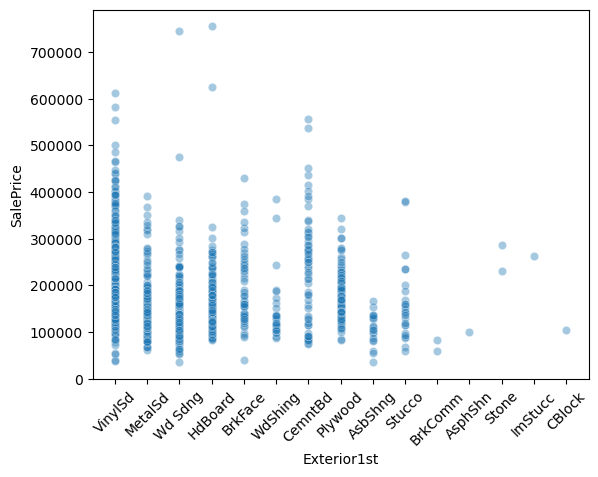

In [93]:
sns.scatterplot(
    x=housing_data["Exterior1st"],
    y=housing_data["SalePrice"],
    alpha=0.4
)
plt.xticks(rotation=45)
plt.show()

In [94]:
X = housing_data.drop(columns=["SalePrice","Exterior1st"])
y = housing_data["SalePrice"]

X["MSZoning"] = X["MSZoning"].map({"RL": 0, "RM": 1,"C (all)": 2,"FV": 3,"RH": 4})
X["LotConfig"] = X["LotConfig"].map({"Inside": 0, "FR2": 1,"Corner": 2,"CulDSac": 3,"FR3": 4})
X["BldgType"] = X["BldgType"].map({"1Fam": 0, "2fmCon": 1,"Duplex": 2,"TwnhsE": 3,"Twnhs": 4})

<Axes: xlabel='BldgType', ylabel='SalePrice'>

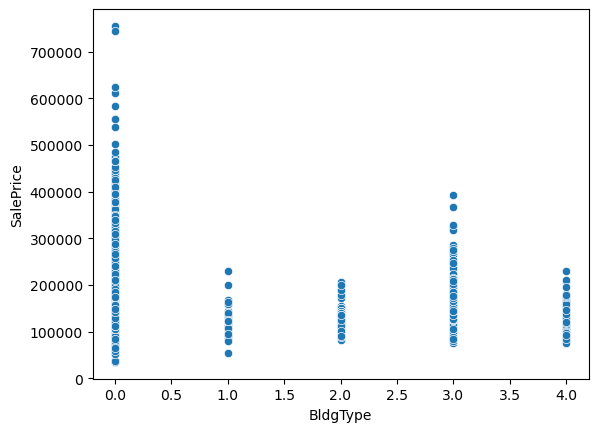

In [95]:
sns.scatterplot(x=X["BldgType"], y=housing_data["SalePrice"])

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [97]:
X_test.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF
892,892,20,0,8414,0,0,8,1963,2003,0.0,1059.0
1105,1105,60,0,12256,2,0,5,1994,1995,0.0,1463.0
413,413,30,1,8960,0,0,6,1927,1950,0.0,1008.0
522,522,50,1,5000,2,0,7,1947,1950,0.0,1004.0
1036,1036,20,0,12898,0,0,5,2007,2008,0.0,1620.0


In [98]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [99]:
y_pred = model.predict(X_test)

In [100]:
y_pred

array([190244.33545727, 252476.77430795, 113769.7341189 , 144476.35077827,
       261605.92542177, 126169.84463221, 181825.97340376, 119063.071223  ,
        97697.91722918, 145045.06751275, 115512.67151277, 143192.66375528,
       109416.65737531, 245536.57005109, 212096.27316859, 176180.96331605,
       211055.42581774, 177250.5414452 , 103550.35783473, 238916.70257565,
       165964.36906629, 215327.93380216, 206546.74352219, 162418.89924395,
       229784.61347172, 177569.52366108, 234998.75818261, 121134.17833226,
       212812.88124743, 214419.60984875, 108475.11411482, 224978.49063159,
       219779.59995306, 134716.09920357, 262673.83944886, 159244.60492095,
       166020.34166589, 210946.81241838, 252023.92975976,  53363.47581748,
       112168.9535885 , 210841.58722975, 145385.08037936, 296229.15730025,
       136832.3192983 ,  89337.23065683, 125660.1983662 , 149837.67373188,
       294548.62432995, 140515.01313748, 117896.52043552, 207878.08477115,
       100294.26320622, 2

In [101]:
y_test

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
          ...   
479      89471.0
1361    260000.0
802     189000.0
651     108000.0
722     124500.0
Name: SalePrice, Length: 292, dtype: float64

In [102]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("r-squared:", r2)


r-squared: 0.6174147995226946
